In [21]:
import os
import math
import time
import random
import zipfile
from glob import glob
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import torchvision.transforms as T
from torchvision.utils import make_grid, save_image
from IPython.display import Image as IPImage, display

import gdown

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

seed = 42
random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
torch.backends.cudnn.benchmark = True

In [22]:
url = "https://drive.google.com/uc?id=1gSDDLRtLRj430JxUfwdmcBLx0Md_2mc4"
zip_path = "/content/fifa_faces.zip"

if not os.path.exists(zip_path):
    gdown.download(url, zip_path, quiet=False)
else:
    print("El ZIP ya existe")

extract_dir = "/content/fifa_faces"
os.makedirs(extract_dir, exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_dir)

print("Contenido descomprimido en:", extract_dir)

El ZIP ya existe
Contenido descomprimido en: /content/fifa_faces


In [23]:
src_dir = "/content/fifa_faces/Images"
dst_dir = "/content/fifa_faces_clean/all"

os.makedirs(dst_dir, exist_ok=True)

exts = (".jpg", ".jpeg", ".png", ".webp", ".bmp")
paths = []
for e in exts:
    paths += glob(os.path.join(src_dir, f"*{e}"))
    paths += glob(os.path.join(src_dir, f"*{e.upper()}"))

print("Archivos encontrados en Images/:", len(paths))

ok = 0
bad = 0

for p in paths:
    try:
        im = Image.open(p)
        im = im.convert("RGB")
        im.load()

        base = os.path.splitext(os.path.basename(p))[0]
        out_path = os.path.join(dst_dir, f"{base}.png")
        im.save(out_path, format="PNG")
        ok += 1
    except Exception:
        bad += 1

print("Guardadas válidas:", ok)
print("Corruptas/no soportadas:", bad)

n_clean = len([f for f in os.listdir(dst_dir) if f.lower().endswith(".png")])
print("Total en carpeta limpia:", n_clean)

if n_clean == 0:
    raise ValueError("No quedaron imágenes válidas. Revisa el contenido en /content/fifa_faces/Images")

Archivos encontrados en Images/: 18207
Guardadas válidas: 15234
Corruptas/no soportadas: 2973
Total en carpeta limpia: 15234


In [24]:
class FlatImageDataset(Dataset):
    def __init__(self, root, transform=None):
        self.paths = sorted(glob(os.path.join(root, "*.png")))
        if len(self.paths) == 0:
            raise RuntimeError(f"No se encontraron PNGs en {root}")
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert("RGB")
        if self.transform is not None:
            img = self.transform(img)
        return img

img_size = 64
transform = T.Compose([
    T.Resize(img_size),
    T.CenterCrop(img_size),
    T.ToTensor(),
    T.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])

dataset = FlatImageDataset(dst_dir, transform=transform)
len(dataset)

15234

In [25]:
batch_size = 128
num_workers = 2

loader = DataLoader(
    dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
    pin_memory=True,
    drop_last=True,
)

x = next(iter(loader))
x.shape, x.min().item(), x.max().item()

(torch.Size([128, 3, 64, 64]), -1.0, 1.0)

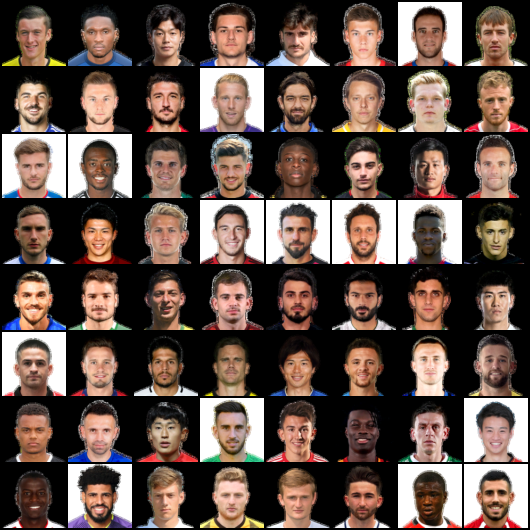

In [26]:
out_dir = "/content/dcgan_fifa"
os.makedirs(out_dir, exist_ok=True)
os.makedirs(os.path.join(out_dir, "samples"), exist_ok=True)
os.makedirs(os.path.join(out_dir, "checkpoints"), exist_ok=True)

def denorm(x):
    return (x * 0.5 + 0.5).clamp(0, 1)

grid = make_grid(denorm(x[:64]), nrow=8)
save_image(grid, os.path.join(out_dir, "real_grid.png"))
display(IPImage(os.path.join(out_dir, "real_grid.png")))

In [27]:
nz = 128
ngf = 64
ndf = 64
nc = 3

class Generator(nn.Module):
    def __init__(self, nz=128, ngf=64, nc=3):
        super().__init__()
        self.net = nn.Sequential(
            nn.ConvTranspose2d(nz, ngf * 8, 4, 1, 0, bias=False),
            nn.BatchNorm2d(ngf * 8),
            nn.ReLU(True),

            nn.ConvTranspose2d(ngf * 8, ngf * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 4),
            nn.ReLU(True),

            nn.ConvTranspose2d(ngf * 4, ngf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 2),
            nn.ReLU(True),

            nn.ConvTranspose2d(ngf * 2, ngf, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf),
            nn.ReLU(True),

            nn.ConvTranspose2d(ngf, nc, 4, 2, 1, bias=False),
            nn.Tanh(),
        )

    def forward(self, z):
        return self.net(z)

class Discriminator(nn.Module):
    def __init__(self, ndf=64, nc=3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(nc, ndf, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(ndf, ndf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 2),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(ndf * 2, ndf * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 4),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(ndf * 4, ndf * 8, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 8),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(ndf * 8, 1, 4, 1, 0, bias=False),
        )

    def forward(self, x):
        return self.net(x).view(-1)

def weights_init(m):
    classname = m.__class__.__name__
    if classname.find("Conv") != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif classname.find("BatchNorm") != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

G = Generator(nz=nz, ngf=ngf, nc=nc).to(device)
D = Discriminator(ndf=ndf, nc=nc).to(device)
G.apply(weights_init)
D.apply(weights_init)

sum(p.numel() for p in G.parameters()), sum(p.numel() for p in D.parameters())

(3806080, 2765568)

In [28]:
lr = 2e-4
beta1 = 0.5
beta2 = 0.999
epochs = 50

criterion = nn.BCEWithLogitsLoss()
optG = optim.Adam(G.parameters(), lr=lr, betas=(beta1, beta2))
optD = optim.Adam(D.parameters(), lr=lr, betas=(beta1, beta2))

fixed_noise = torch.randn(64, nz, 1, 1, device=device)
scaler = torch.cuda.amp.GradScaler(enabled=(device.type == "cuda"))

/tmp/ipython-input-1289915278.py:11: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(device.type == "cuda"))


In [29]:
def save_samples(step):
    G.eval()
    with torch.no_grad():
        fake = G(fixed_noise)
    grid = make_grid(denorm(fake), nrow=8)
    out_path = os.path.join(out_dir, "samples", f"fake_{step:07d}.png")
    save_image(grid, out_path)
    G.train()
    return out_path

def save_ckpt(step, epoch):
    ckpt = {
        "G": G.state_dict(),
        "D": D.state_dict(),
        "optG": optG.state_dict(),
        "optD": optD.state_dict(),
        "step": step,
        "epoch": epoch,
        "nz": nz,
        "ngf": ngf,
        "ndf": ndf,
        "img_size": img_size,
        "seed": seed,
    }
    path = os.path.join(out_dir, "checkpoints", f"dcgan_{step:07d}.pt")
    torch.save(ckpt, path)
    return path

In [30]:
step = 0
log_every = 100
sample_every = 500
ckpt_every = 2000

G.train()
D.train()

t0 = time.time()

for epoch in range(1, epochs + 1):
    for real in loader:
        real = real.to(device, non_blocking=True)
        bsz = real.size(0)

        real_labels = torch.ones(bsz, device=device)
        fake_labels = torch.zeros(bsz, device=device)

        optD.zero_grad(set_to_none=True)
        with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):
            real_logits = D(real)
            d_real = criterion(real_logits, real_labels)

            noise = torch.randn(bsz, nz, 1, 1, device=device)
            fake = G(noise).detach()
            fake_logits = D(fake)
            d_fake = criterion(fake_logits, fake_labels)

            d_loss = d_real + d_fake

        scaler.scale(d_loss).backward()
        scaler.step(optD)

        optG.zero_grad(set_to_none=True)
        with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):
            noise = torch.randn(bsz, nz, 1, 1, device=device)
            fake = G(noise)
            fake_logits = D(fake)
            g_loss = criterion(fake_logits, real_labels)

        scaler.scale(g_loss).backward()
        scaler.step(optG)
        scaler.update()

        if step % log_every == 0:
            with torch.no_grad():
                d_real_sig = torch.sigmoid(real_logits).mean().item()
                d_fake_sig = torch.sigmoid(fake_logits).mean().item()
            elapsed = time.time() - t0
            print(
                f"epoch {epoch:03d}/{epochs} | step {step:07d} | "
                f"d_loss {d_loss.item():.4f} | g_loss {g_loss.item():.4f} | "
                f"D(x) {d_real_sig:.3f} | D(G(z)) {d_fake_sig:.3f} | "
                f"t {elapsed/60:.1f} min"
            )

        if step % sample_every == 0:
            p = save_samples(step)
            display(IPImage(p))

        if step > 0 and step % ckpt_every == 0:
            save_ckpt(step, epoch)

        step += 1

p = save_samples(step)
display(IPImage(p))
save_ckpt(step, epochs)

print("Listo. Carpeta:", out_dir)

Output hidden; open in https://colab.research.google.com to view.

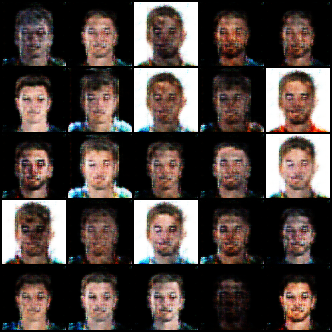

In [31]:
def generate(n=16, trunc=None):
    G.eval()
    with torch.no_grad():
        z = torch.randn(n, nz, 1, 1, device=device)
        if trunc is not None:
            z = z.clamp(-trunc, trunc)
        fake = G(z)
    G.train()
    grid = make_grid(denorm(fake), nrow=int(math.sqrt(n)))
    out_path = os.path.join(out_dir, f"generated_{n}.png")
    save_image(grid, out_path)
    return out_path

display(IPImage(generate(25, trunc=1.5)))